In [2]:
import matplotlib.pyplot as plt
import os
import sys
sys.path.append('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/scripts')
from mge_general import MGEFitter
from astropy.io import fits
import numpy as np
import mgefit as mge

In [4]:
img_f200 = fits.open('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/IFU/photometry/f200w_ifu_coadd_masked.fits')[0].data
dust_mask = fits.open('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/dust_mask/f200_mask_1.fits')[0].data

nan_mask = np.isnan(img_f200)
if np.any(nan_mask):
    print(f"Found {np.sum(nan_mask)} NaN pixels in the image. Replacing with 0 and adding to dust mask.")
    img_f200[nan_mask] = 0.0
    dust_mask = dust_mask | nan_mask

checkplot_dir = "/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/mge_test"


Found 79853441 NaN pixels in the image. Replacing with 0 and adding to dust mask.


In [5]:
# load the mge fit

runner = MGEFitter(
img_f200,
dust_mask,
pixel_scale=0.031,
subtract_sky=False,
linear=False,
ngauss=20,
plot=True,
checkplot_dir=checkplot_dir,
cache_dir=checkplot_dir,
prefix="sombrero_f200",
contour_half_size_arcsec=80,
contour_oversample=1,
n_sectors=24,
#center=(7537.219884279368, 7332.548985227105),   # (x, y)
#pa_deg=87.2,
#eps=0.35,
#theta_deg=87.2,            # optional
)

In [6]:
res = runner.run_fit()

In [9]:
res = runner.results_dict()

In [10]:
# make the contour plot from the mgefit
mge_fit = res['mgefit']

KeyboardInterrupt: 

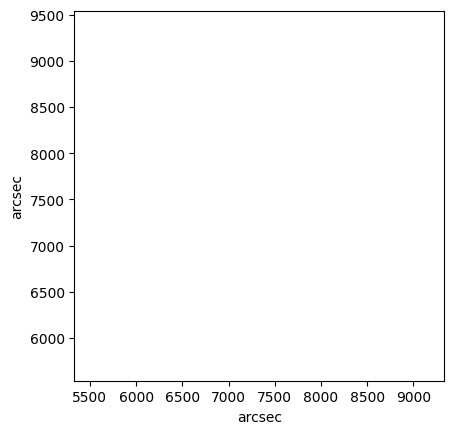

: 

In [ ]:
mge.print_contours(
    img_f200, res['theta_deg'], res['center_pix'][0], res['center_pix'][1], mge_fit.sol, scale=0.031,
)
# zoom into the center
plt.xlim(res['center_pix'][0] - 2000, res['center_pix'][0] + 2000)
plt.ylim(res['center_pix'][1] - 2000, res['center_pix'][1] + 2000)
plt.savefig(os.path.join(checkplot_dir, "mge_fit_contours.png"), dpi=600)
plt.show()
